In [1]:
import pandas as pd
import numpy as np

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful!")

Imports successful!


In [2]:
dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})


In [3]:
print(dataset["train"].column_names)

['flags', 'instruction', 'category', 'intent', 'response']


In [4]:
for i in range(5):
    print(f"\nSample {i}:")
    print(dataset["train"][i])


Sample 0:
{'flags': 'B', 'instruction': 'question about cancelling order {{Order Number}}', 'category': 'ORDER', 'intent': 'cancel_order', 'response': "I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."}

Sample 1:
{'flags': 'BQZ', 'instruction': 'i have a question about cancelling oorder {{Order Number}}', 'category': 'ORDER', 'intent': 'cancel_order', 'response': "I've been informed that you have a question about canceling order {{Order Number}}. I'm here to assist you! Please go ahead and let me know what specific question you have, and I'll provide you with all the information and guidance you need. Your satisfaction is my top priority."}

Sample 2:
{'flags': 'BLQZ', 'instruction': 'i need help cancelling puchase {{Order Number}}', 'category': 'ORDER', 'intent': 'cancel_order', 'response': "I can sense that you're seekin

In [5]:
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (26872, 5)

Columns:
['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [6]:
print("Number of intents:", df["category"].nunique())

print("\nIntent distribution:")
print(df["category"].value_counts())

Number of intents: 11

Intent distribution:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [7]:
print(df.columns.tolist())

['flags', 'instruction', 'category', 'intent', 'response']


In [8]:
print(df.isnull().sum())

flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64


In [9]:
X = df["instruction"].astype(str)
y = df["category"].astype(str)

print("Number of samples:", len(X))
print("Number of intents:", y.nunique())

Number of samples: 26872
Number of intents: 11


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 18810
Validation size: 4031
Test size: 4031


In [11]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word = word_tfidf.transform(X_val)
X_test_word = word_tfidf.transform(X_test)

print("Train shape:", X_train_word.shape)
print("Validation shape:", X_val_word.shape)
print("Test shape:", X_test_word.shape)

Train shape: (18810, 4906)
Validation shape: (4031, 4906)
Test shape: (4031, 4906)


In [12]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_word, y_train)

print("LinearSVC trained successfully!")

LinearSVC trained successfully!


In [13]:
y_val_pred_svm = svm_model.predict(X_val_word)

svm_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_svm
)

svm_val_f1 = f1_score(
    y_val,
    y_val_pred_svm,
    average="macro"
)

print("LinearSVC Validation Accuracy:", svm_val_accuracy)
print("LinearSVC Validation Macro F1:", svm_val_f1)

LinearSVC Validation Accuracy: 0.9985115355991069
LinearSVC Validation Macro F1: 0.9985865562227633


In [14]:
print(
    classification_report(
        y_val,
        y_val_pred_svm
    )
)

              precision    recall  f1-score   support

     ACCOUNT       0.99      1.00      1.00       898
      CANCEL       0.99      1.00      1.00       142
     CONTACT       1.00      1.00      1.00       300
    DELIVERY       1.00      1.00      1.00       299
    FEEDBACK       1.00      1.00      1.00       300
     INVOICE       1.00      1.00      1.00       300
       ORDER       1.00      1.00      1.00       598
     PAYMENT       1.00      0.99      0.99       299
      REFUND       1.00      1.00      1.00       449
    SHIPPING       1.00      1.00      1.00       296
SUBSCRIPTION       1.00      1.00      1.00       150

    accuracy                           1.00      4031
   macro avg       1.00      1.00      1.00      4031
weighted avg       1.00      1.00      1.00      4031



In [15]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_word, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [16]:
y_val_pred_lr = lr_model.predict(X_val_word)

lr_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_lr
)

lr_val_f1 = f1_score(
    y_val,
    y_val_pred_lr,
    average="macro"
)

print("Logistic Regression Validation Accuracy:", lr_val_accuracy)
print("Logistic Regression Validation Macro F1:", lr_val_f1)

Logistic Regression Validation Accuracy: 0.9962788389977673
Logistic Regression Validation Macro F1: 0.9964140052216947


In [17]:
comparison = pd.DataFrame({
    "Model": [
        "LinearSVC",
        "Logistic Regression"
    ],
    "Validation Accuracy": [
        svm_val_accuracy,
        lr_val_accuracy
    ],
    "Validation Macro F1": [
        svm_val_f1,
        lr_val_f1
    ]
})

comparison.sort_values(
    by="Validation Macro F1",
    ascending=False
)

,Model,Validation Accuracy,Validation Macro F1
0,LinearSVC,0.998512,0.998587
1,Logistic Regression,0.996279,0.996414


In [18]:
if svm_val_f1 >= lr_val_f1:
    best_intent_model = svm_model
    best_intent_name = "LinearSVC"
else:
    best_intent_model = lr_model
    best_intent_name = "Logistic Regression"

print("Best Intent Model:", best_intent_name)

Best Intent Model: LinearSVC


In [20]:
y_test_pred = best_intent_model.predict(X_test_word)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

print("Final Test Accuracy:", test_accuracy)
print("Final Test Macro F1:", test_f1)

Final Test Accuracy: 0.9982634581989581
Final Test Macro F1: 0.9985549265763095


In [21]:
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

              precision    recall  f1-score   support

     ACCOUNT       0.99      1.00      1.00       898
      CANCEL       1.00      1.00      1.00       143
     CONTACT       1.00      1.00      1.00       300
    DELIVERY       1.00      1.00      1.00       299
    FEEDBACK       1.00      1.00      1.00       299
     INVOICE       1.00      1.00      1.00       300
       ORDER       1.00      1.00      1.00       598
     PAYMENT       1.00      0.99      0.99       300
      REFUND       1.00      1.00      1.00       449
    SHIPPING       1.00      1.00      1.00       295
SUBSCRIPTION       1.00      1.00      1.00       150

    accuracy                           1.00      4031
   macro avg       1.00      1.00      1.00      4031
weighted avg       1.00      1.00      1.00      4031



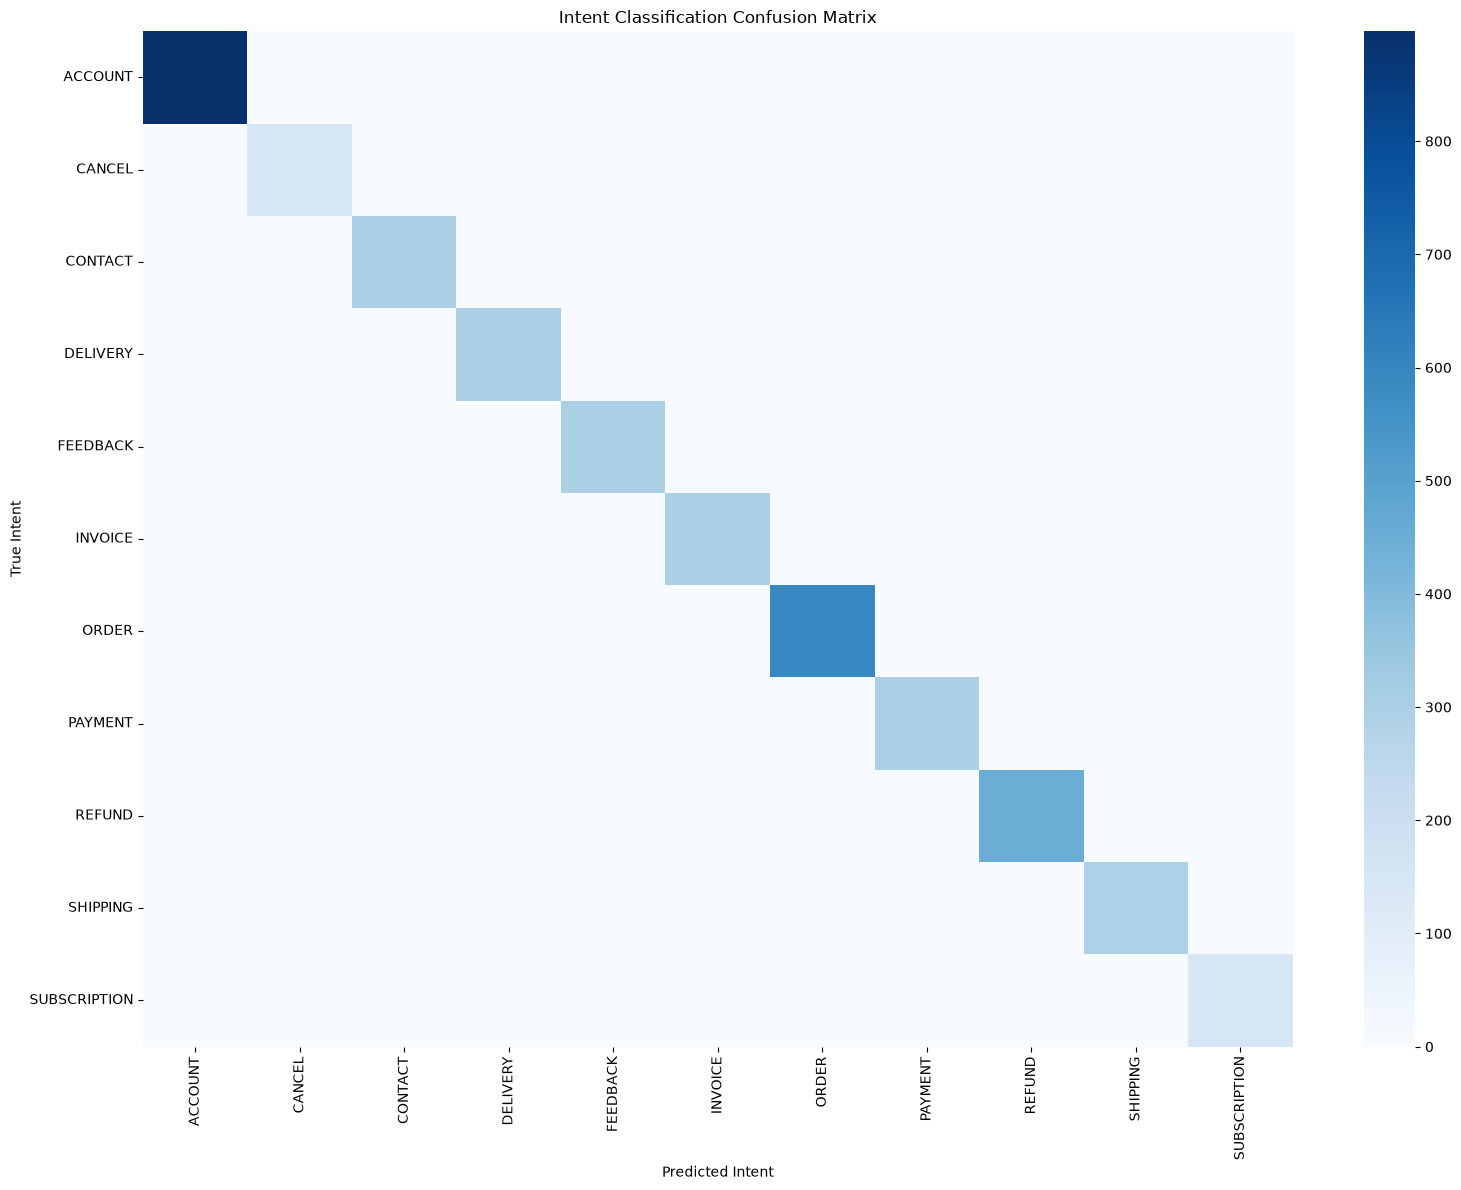

In [22]:
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=sorted(y_test.unique())
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.title("Intent Classification Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
test_messages = [
    "Where is my order?",
    "I want to cancel my order",
    "I need a refund",
    "I forgot my password",
    "My payment was declined",
    "I am very angry about this service",
    "Thank you for your help",
    "Hello, I need some assistance"
]

test_vectors = word_tfidf.transform(test_messages)
predictions = best_intent_model.predict(test_vectors)

for message, intent in zip(test_messages, predictions):
    print(f"Message: {message}")
    print(f"Predicted Intent: {intent}")
    print("-" * 60)

Message: Where is my order?
Predicted Intent: ORDER
------------------------------------------------------------
Message: I want to cancel my order
Predicted Intent: ORDER
------------------------------------------------------------
Message: I need a refund
Predicted Intent: REFUND
------------------------------------------------------------
Message: I forgot my password
Predicted Intent: ACCOUNT
------------------------------------------------------------
Message: My payment was declined
Predicted Intent: PAYMENT
------------------------------------------------------------
Message: I am very angry about this service
Predicted Intent: FEEDBACK
------------------------------------------------------------
Message: Thank you for your help
Predicted Intent: FEEDBACK
------------------------------------------------------------
Message: Hello, I need some assistance
Predicted Intent: ORDER
------------------------------------------------------------


In [26]:
# Safely inspect current variables

variables = dict(globals())

for name, value in variables.items():
    if any(word in name.lower() for word in [
        "intent",
        "vector",
        "tfidf",
        "model",
        "classifier"
    ]):
        print(f"{name} -> {type(value)}")

TfidfVectorizer -> <class 'type'>
word_tfidf -> <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
svm_model -> <class 'sklearn.svm._classes.LinearSVC'>
lr_model -> <class 'sklearn.linear_model._logistic.LogisticRegression'>
best_intent_model -> <class 'sklearn.svm._classes.LinearSVC'>
best_intent_name -> <class 'str'>
test_vectors -> <class 'scipy.sparse._csr.csr_matrix'>
intent -> <class 'str'>
MODELS_DIR -> <class 'str'>


In [27]:
import os
import joblib

PROJECT_DIR = r"C:\Users\Administrator\Downloads\NLP_Final_Project"
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(MODELS_DIR, exist_ok=True)

# Save Intent model
joblib.dump(
    best_intent_model,
    os.path.join(MODELS_DIR, "intent_model.pkl")
)

# Save TF-IDF vectorizer
joblib.dump(
    word_tfidf,
    os.path.join(MODELS_DIR, "intent_vectorizer.pkl")
)

print("Intent model saved successfully!")
print("Best model:", best_intent_name)
print("\nSaved files:")
for file in os.listdir(MODELS_DIR):
    print(file)

Intent model saved successfully!
Best model: LinearSVC

Saved files:
intent_model.pkl
intent_vectorizer.pkl
language_detector_model.pkl
language_detector_vectorizer.pkl
